In [2]:
%load_ext autoreload
%autoreload 2

import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
import random
import sys
from tifffile import imread

# Change this folder to where the cloned `alignment` repository is
sys.path.insert(0, '/Users/elysiaye/alignment')

# Change this folder to where the cloned `caImageAnalysis` repository is
sys.path.insert(0, '/Users/elysiaye/caImageAnalysis')

from alignment import caiman_memmap_reader, minmax_scaler
from registration import sitkalignment

logging.getLogger('matplotlib').setLevel(logging.ERROR)

cv2 not available


#### To align the hindbrain, we will use a plane in the functional images of each recording. So unlike vagal recordings, which are aligned based on a single z-projected anatomy image, we will align hindbrain neurons based on a plane in the volumetric functional imaging data.

In [3]:
# Folder where the experiment folders are
data_folder = Path(fr'/Volumes/Kobi/DOI_animals_good')

# Target data
# CHANGE THIS exp_folder to each individual fish's experiment folder
exp_folder_name = 'elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925'
exp_folder = Path(data_folder).joinpath(exp_folder_name)

# Reference data for alignment
source_img_path = Path(fr'/Users/elysiaye/Downloads/anatomystack-000_Cycle00001_Ch2_000001.ome.tif')

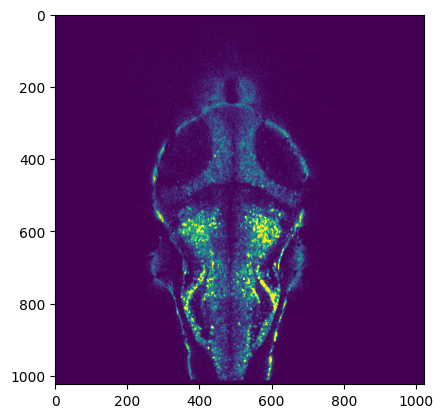

In [4]:
# Load the reference (i.e., source) image
anatomy_plane_of_interest = 11 # need to only choose one plane

source_img_stack = imread(source_img_path)

source_img = source_img_stack[anatomy_plane_of_interest, :, :]
source_img = sitkalignment.embed_image(source_img, 1024) # matching image sizes to 1024x1024

source_img = source_img / source_img.max() # rescaling pixel brightness
source_img *= 2**12

plt.imshow(source_img, vmax=700)

# Find best target plane

Gather all target images that you align to the source image into a list if you want to run z alignment

In [5]:
import re

batch_path = exp_folder.joinpath("mesmerize-batch/batch.pickle")
df = pd.read_pickle(Path(batch_path))
df = df[df["algo"] == "mcorr"]

# Build uuid -> plane mapping from available metadata.
uuid_to_plane = {}

# 1) Direct numeric plane columns (if present)
plane_col = None
for candidate in ["plane", "z", "z_plane", "slice", "plane_idx", "plane_index"]:
    if candidate in df.columns:
        plane_col = candidate
        break

if plane_col is not None:
    uuid_to_plane.update({
        str(row.uuid): int(row[plane_col])
        for _, row in df[["uuid", plane_col]].dropna().iterrows()
    })

# 2) Parse from item_name/input path patterns like img_stack_5
for _, row in df.iterrows():
    uid = str(row.uuid)
    if uid in uuid_to_plane:
        continue
    for field in ["item_name", "input_movie_path"]:
        if field not in df.columns:
            continue
        text = str(row[field])
        m = re.search(r"img_stack[_\-\s]?(\d+)", text, flags=re.IGNORECASE)
        if m:
            uuid_to_plane[uid] = int(m.group(1))
            break

filenames = set(df.uuid.astype(str))
target_items = []  # (mmap_path, detected_plane, uuid)

with os.scandir(exp_folder.joinpath("mesmerize-batch")) as entries:
    for entry in entries:
        if entry.name in filenames:
            with os.scandir(entry.path) as subentries:
                for subentry in subentries:
                    # Skip AppleDouble sidecar files (._*) and keep real memmaps only.
                    if not subentry.name.endswith(".mmap") or subentry.name.startswith("._"):
                        continue

                    # Prefer batch metadata (uuid -> plane) over path regex. Paths often contain
                    # extra digits (stack index, etc.) that do not match df.plane in unrolled_temporal.h5.
                    detected_plane = uuid_to_plane.get(entry.name)
                    if detected_plane is None:
                        print('planes not detected by uuid_to_plane')
                        m = re.search(
                            r"(?:^|[_\-\s])(plane|z|slice|img_stack)[_\-\s]?(\d+)(?:[_\-\s]|$)",
                            subentry.path,
                            flags=re.IGNORECASE,
                        )
                        if m:
                            detected_plane = int(m.group(2))
                    target_items.append((subentry.path, detected_plane, entry.name))

# Keep deterministic ordering: known planes in ascending order, then unknowns by uuid/path.
target_items.sort(
    key=lambda x: (
        x[1] is None,
        x[1] if x[1] is not None else 10**9,
        x[2],
        x[0],
    )
)

target_img_lst = []
target_img_by_plane = {}
plane_to_uuid = {}
for img_path, detected_plane, uid in target_items:
    img_stack = caiman_memmap_reader(img_path, mode="r")

    target_img = np.nanstd(img_stack, axis=0)
    target_img = target_img / target_img.max()
    target_img *= 2**12

    # Rotate target image 90 degrees right (clockwise); matches COM mapping below.
    target_img = np.rot90(target_img, k=3)
    target_img = sitkalignment.embed_image(target_img, 1024)

    target_img_lst.append(target_img)
    if detected_plane is not None:
        target_img_by_plane[detected_plane] = target_img
        plane_to_uuid[detected_plane] = uid

print(f"Loaded {len(target_img_lst)} target images")
print(f"Detected planes: {sorted(target_img_by_plane.keys())}")
print(f"Plane -> UUID mapping: {dict(sorted(plane_to_uuid.items()))}")
missing = [uid for _, detected_plane, uid in target_items if detected_plane is None]
if len(missing) > 0:
    print(f"[WARN] No plane detected for {len(missing)} entries")


Loaded 11 target images
Detected planes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Plane -> UUID mapping: {0: '1a515408-b1e7-430a-af0e-5eea916c3c59', 1: '00ff7dc0-687e-459e-a8ba-d646c0fa5786', 2: '0124b8df-1f13-4be9-b22d-0a8ea655296d', 3: '6658a75d-3483-48cb-bf33-3e026a38a6d1', 4: '5d941131-6365-429a-81fd-754a987bb0b8', 5: '11bc8971-065d-4bac-be19-a594e6f1aefe', 6: 'ae7df468-d4e5-4948-833f-92a02f8ff53a', 7: '2338d389-6dff-4d2e-9b87-0d1a01a676ac', 8: '50526d09-8f2f-492b-b09a-6b6205622bc9', 9: 'c77ba15f-8031-476e-8a44-f1e41878dbc9', 10: 'dcf9a262-c1a7-445f-a166-e714c128d457'}


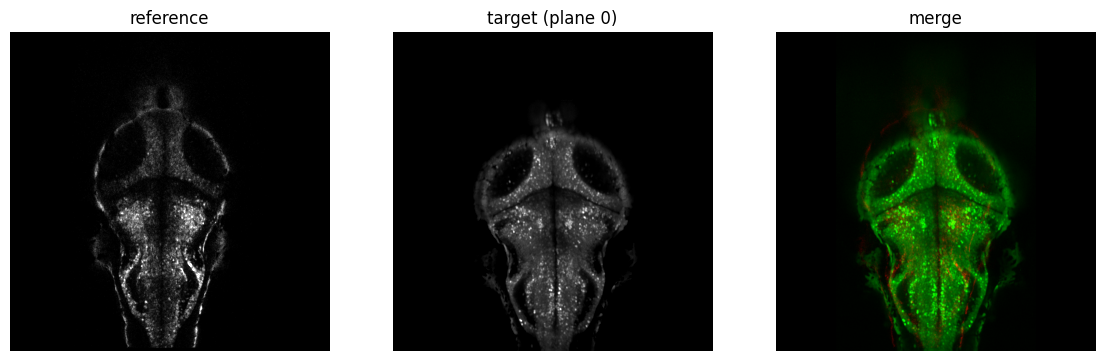

In [ ]:
# Visualize unaligned source and target images
# Change the vmin and vmax settings for better visualization and better alignment
# Increasing the contrast of landmarks helps with the alignment
#
# `plane` must match df.plane (from batch metadata / filenames), not list position.
# Prefer target_img_by_plane[plane]; do not use target_img_lst[plane] unless planes are 0..n-1 by construction.
plane = 0
target_vmin = 200
target_vmax = 3000
source_vmax = 1000
plot_img_line_xval = 0  # blocking out top of functional image with 0's
source_img_line_xval = 0  # blocking out top of reference image with 0's

########################################

if not (isinstance(target_img_by_plane, dict) and target_img_by_plane):
    raise ValueError("target_img_by_plane is missing or empty. Build plane mapping first.")

if plane not in target_img_by_plane:
    raise ValueError(
        f"Plane {plane} not available. Detected planes: {sorted(target_img_by_plane.keys())}"
    )

plot_img = target_img_by_plane[plane]
target_label = f"target (plane {plane})"

# Full FOV for this plane (used in registration viz + must match `plane`)
target_img = plot_img

fig, ax = plt.subplots(1, 3, figsize=(14, 6))

_plot_img = plot_img.copy()
_plot_img[0:plot_img_line_xval] = 0

_source_img = source_img.copy()
_source_img[0:source_img_line_xval] = 0

ax[0].imshow(
    _source_img,
    cmap="gray",
    vmin=0,
    vmax=source_vmax  # max is 4096
)
ax[1].imshow(
    _plot_img, 
    cmap="gray",
    vmin=target_vmin,
    vmax=target_vmax  # max is 4096
)

[a.axis("off") for a in ax]

merge = np.zeros(
    (_source_img.shape[0], _source_img.shape[1], 3)
)  # assumes same size images
merge[:, :, 0] = 2 * _source_img / _source_img.max()
merge[:, :, 1] = 2 * _plot_img / _plot_img.max()
ax[-1].imshow(merge)

ax[0].set_title("reference")
ax[1].set_title(target_label)
ax[-1].set_title("merge")
plt.show()

# Reverse Alignment

In [7]:
%%time
# Reverse alignment: Elastix maps this functional plane onto the reference.
if "target_img_by_plane" in globals() and isinstance(target_img_by_plane, dict) and len(target_img_by_plane) > 0:
    if plane not in target_img_by_plane:
        raise ValueError(
            f"Plane {plane} not in target_img_by_plane. Available: {sorted(target_img_by_plane.keys())}"
        )

# Same folder naming as batch pipeline (alignment_rev_plane{plane}).
save_path = exp_folder.joinpath(f"alignment_rev_plane{plane}")

# register_image2 — same argument order as before; use minmax-scaled images like batch alignment
_reg_plot = minmax_scaler(plot_img, vmin=target_vmin, vmax=target_vmax)
_reg_source = minmax_scaler(source_img, vmin=0, vmax=source_vmax)

scale_penalties = [150]
iterations = [(10000, 500)]

registered_images = []
for sp in scale_penalties:
    for it in iterations:
        registered_image = sitkalignment.register_image2(
            _reg_plot, _reg_source, save_path, scalePenalty=sp, iterations=it
        )
        registered_images.append(registered_image)

Installing all components.
InstallingComponents was successful.

ELASTIX version: 5.0.1
Command line options from ElastixBase:
-fMask    unspecified, so no fixed mask used
-mMask    unspecified, so no moving mask used
-out      ./
-threads  unspecified, so all available threads are used
  The default value "true" is used instead.

  From elastix 4.8 it defaults to true!
This may change the behavior of your registrations considerably.

Command line options from TransformBase:
-t0       unspecified, so no initial transform used

Reading images...
Reading images took 0 ms.

  A default pyramid schedule is used.
  A default pyramid schedule is used.
  The default value "false" is used instead.
  The default value "GeometricalCenter" is used instead.
Transform parameters are initialized as: [1, 0, 0, 1, 0, 0]
InitializeTransform took 0.00s
Scales are estimated automatically.
Scales for transform parameters are: [88400.25, 88400.25, 88400.25, 88400.25, 1, 1]
Initialization of all components 

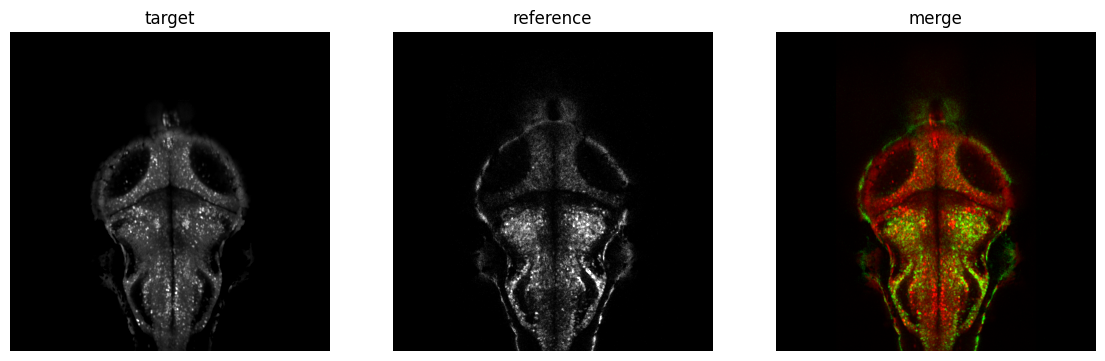

In [8]:
for registered_image in registered_images:
	fig, ax = plt.subplots(1, 3, figsize=(14, 6))

	ax[0].imshow(
		target_img,
		cmap="gray",
		vmin=target_vmin, 
		vmax=target_vmax
	)
	ax[1].imshow(
		registered_image,
		cmap="gray",
		vmin=0, vmax=250
	)

	[a.axis("off") for a in ax]

	merge = np.zeros(
		(target_img.shape[0], target_img.shape[1], 3)
	)  # assumes same size images
	merge[:, :, 0] = 2 * target_img / target_img.max()
	merge[:, :, 1] = 4 * registered_image / registered_image.max()
	ax[-1].imshow(merge)

	ax[0].set_title("target")
	ax[1].set_title("reference")
	ax[-1].set_title("merge")
	plt.show()

# Find points on functional stack back to reference stack

Checking alignment transformations look good

In [27]:
n_points = 10

mypoints = list()
fish_id = int(exp_folder.name.split('_')[-2])
save_path = exp_folder.joinpath("alignment_rev")

df = pd.read_hdf(data_folder.joinpath("temporal_pack_compact.h5"))

# Native functional plane had width 640 on the axis that gets centered into 1024 before display.
# In *current* (rot90 CCW) image coords, shift x by half the padding: (1024 - 640) / 2.
# Then same CCW 90° as np.rot90(..., k=1): scatter (col,row) as (px,py) -> (py, W-1-px).
W_EMBED = 1024
SHIFT_X_CURRENT = (1024 - 640) // 2


def com_to_target_xy(x, y):
    px, py = float(x), float(y)
    ox, oy = py, W_EMBED - 1 - px
    return (ox + SHIFT_X_CURRENT, oy)


coms = random.sample(list(df[(df.fish_id == fish_id) & (df.plane == plane)]["com"]), n_points)
for x, y in coms:
    mypoints.append(com_to_target_xy(x, y))


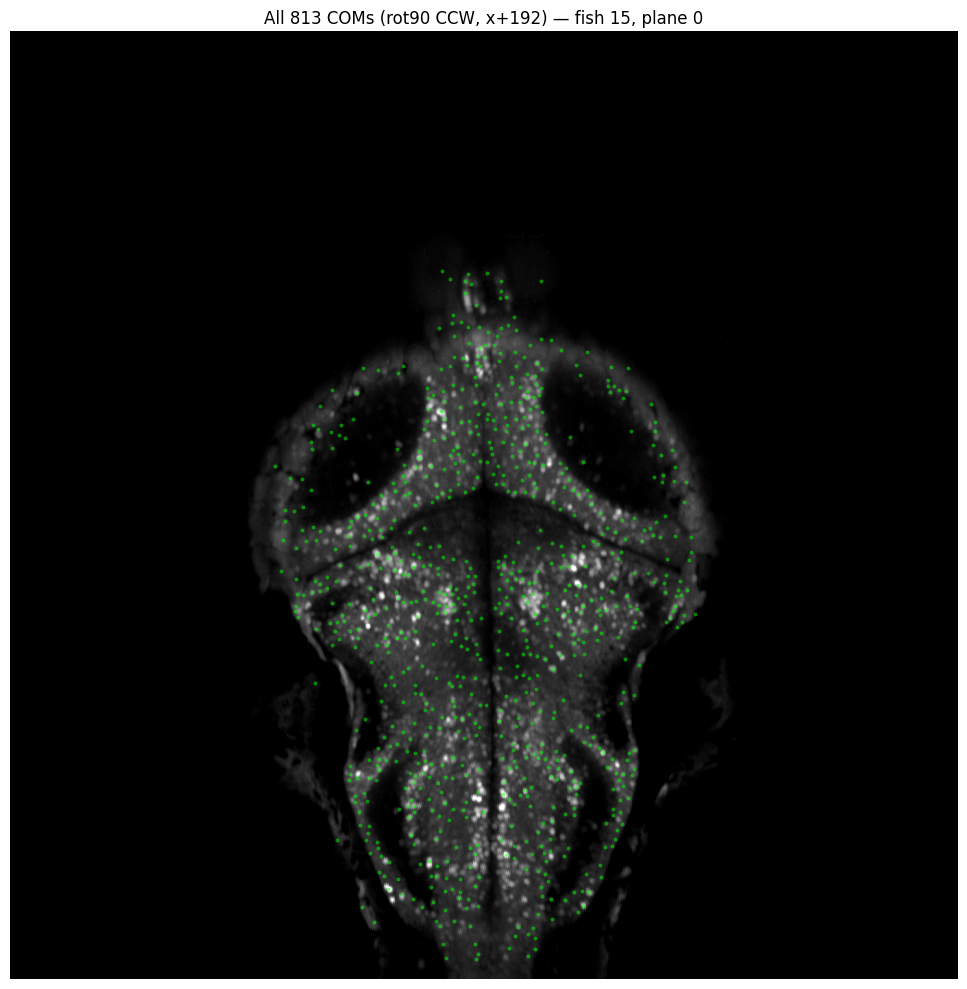

In [28]:
# Diagnostic: all ROI coms for this fish/plane (same `com_to_target_xy` as `mypoints`)
# Requires: plane, target_img_lst, fish_id, data_folder

if "com_to_target_xy" not in globals():
    W_EMBED = 1024
    SHIFT_X_CURRENT = (1024 - 640) // 2

    def com_to_target_xy(x, y):
        px, py = float(x), float(y)
        ox, oy = py, W_EMBED - 1 - px
        return (ox + SHIFT_X_CURRENT, oy)

_tdf = df if "df" in globals() else pd.read_hdf(data_folder.joinpath("temporal_pack_compact.h5"))
_roi_plane = _tdf[(_tdf["fish_id"] == fish_id) & (_tdf["plane"] == plane)]
_all_pts = [com_to_target_xy(x, y) for x, y in _roi_plane["com"]]

_tvmin = globals().get("target_vmin", 500)
_tvmax = globals().get("target_vmax", 3000)

if "target_img_by_plane" in globals() and isinstance(target_img_by_plane, dict) and plane in target_img_by_plane:
    _tgt = target_img_by_plane[plane]
else:
    _tgt = target_img_lst[plane]

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(_tgt, cmap="gray", vmin=_tvmin, vmax=_tvmax)
for p in _all_pts:
    ax.scatter(p[0], p[1], s=8, c="lime", alpha=0.5, linewidths=0)
ax.set_title(
    f"All {len(_all_pts)} COMs (rot90 CCW, x+{SHIFT_X_CURRENT}) — fish {fish_id}, plane {plane}"
)
ax.axis("off")
plt.tight_layout()
plt.show()


In [29]:
rev_points = sitkalignment.transform_points(Path(save_path), mypoints)

ELASTIX version: 5.0.1
Command line options from ElastixBase:
-out      /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev/
-threads  unspecified, so all available threads are used
-def      /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev/point_set.txt
-jac      unspecified, so no det(dT/dx) computed
-jacmat   unspecified, so no dT/dx computed
Calling all ReadFromFile()'s ...
  The default value "false" is used instead.
  The default value "false" is used instead.
  Calling all ReadFromFile()'s took 0.008547 s
Transforming points ...
  The transform is evaluated on some points, specified in the input point file.
  Reading input point file: /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev/point_set.txt
  Input points are specified in world coordinates.
  Number of specified input points: 10
  The input points are transformed.
  The transformed points are saved in: /V

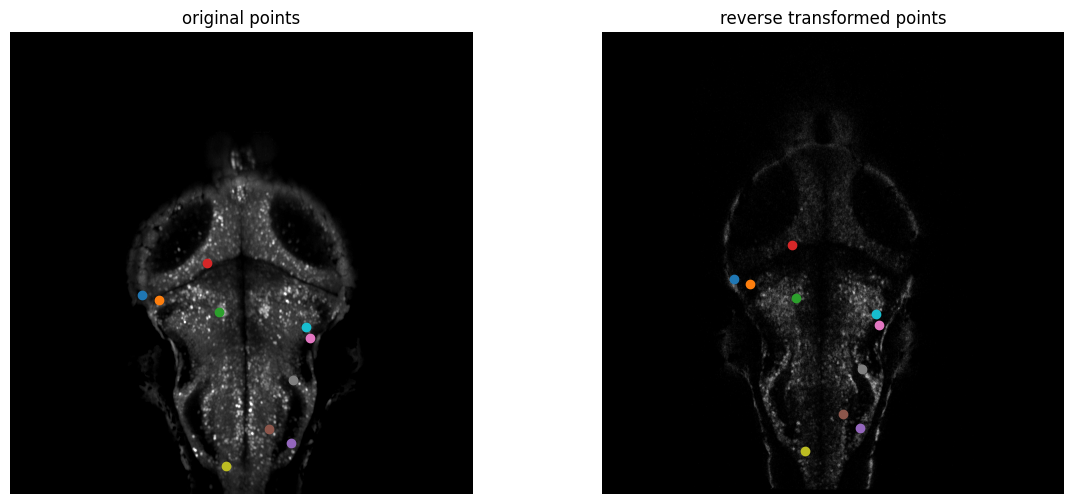

In [30]:
# Plot the original points on the target image vs. transformed points on the reference image
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].imshow(
    target_img_lst[plane],
    cmap="gray",
    vmin=target_vmin,
    vmax=target_vmax 
)
for p in mypoints:
    ax[0].scatter(p[0], p[1])
ax[0].set_title('original points')

ax[1].imshow(
    source_img,
    cmap="gray",
    vmin=0,
    vmax=2000,
)
ax[1].set_title('reverse transformed points')
for p in rev_points:
    ax[1].scatter(p[0], p[1])

[a.axis("off") for a in ax]
plt.show()

## Testing this alignment on multiple planes

ELASTIX version: 5.0.1
Command line options from ElastixBase:
-out      /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev/
-threads  unspecified, so all available threads are used
-def      /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev/point_set.txt
-jac      unspecified, so no det(dT/dx) computed
-jacmat   unspecified, so no dT/dx computed
Calling all ReadFromFile()'s ...
  The default value "false" is used instead.
  The default value "false" is used instead.
  Calling all ReadFromFile()'s took 0.006080 s
Transforming points ...
  The transform is evaluated on some points, specified in the input point file.
  Reading input point file: /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev/point_set.txt
  Input points are specified in world coordinates.
  Number of specified input points: 10
  The input points are transformed.
  The transformed points are saved in: /V

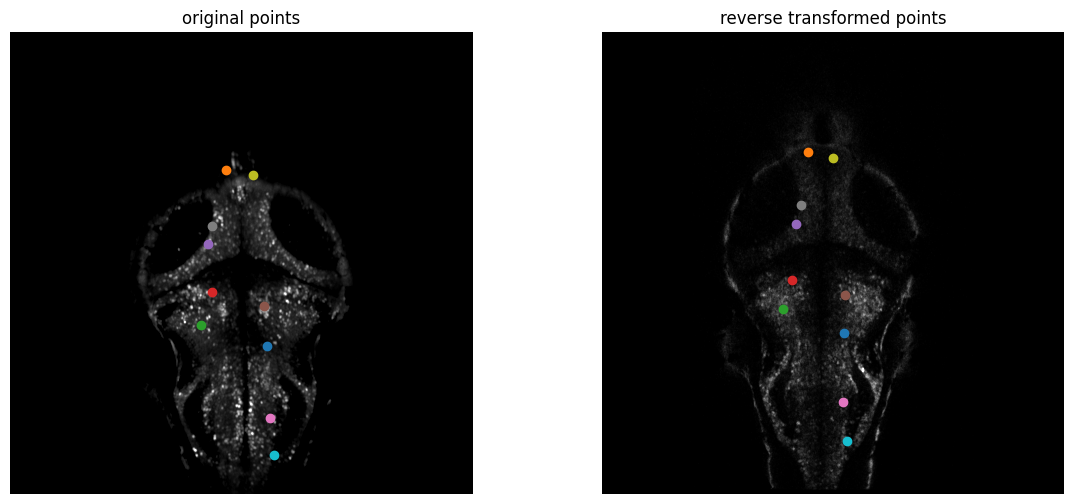

ELASTIX version: 5.0.1
Command line options from ElastixBase:
-out      /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev/
-threads  unspecified, so all available threads are used
-def      /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev/point_set.txt
-jac      unspecified, so no det(dT/dx) computed
-jacmat   unspecified, so no dT/dx computed
Calling all ReadFromFile()'s ...
  The default value "false" is used instead.
  The default value "false" is used instead.
  Calling all ReadFromFile()'s took 0.006246 s
Transforming points ...
  The transform is evaluated on some points, specified in the input point file.
  Reading input point file: /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev/point_set.txt
  Input points are specified in world coordinates.
  Number of specified input points: 10
  The input points are transformed.
  The transformed points are saved in: /V

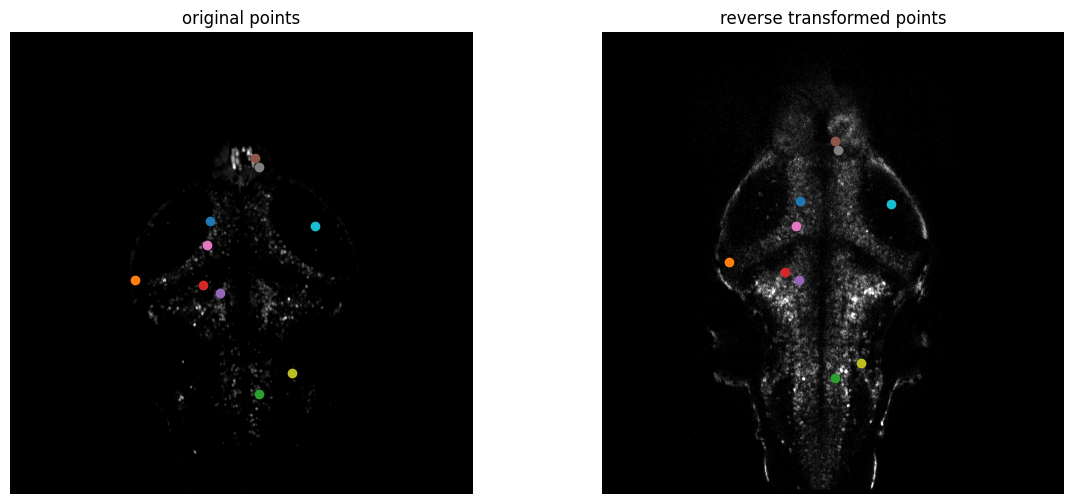

ELASTIX version: 5.0.1
Command line options from ElastixBase:
-out      /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev/
-threads  unspecified, so all available threads are used
-def      /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev/point_set.txt
-jac      unspecified, so no det(dT/dx) computed
-jacmat   unspecified, so no dT/dx computed
Calling all ReadFromFile()'s ...
  The default value "false" is used instead.
  The default value "false" is used instead.
  Calling all ReadFromFile()'s took 0.006284 s
Transforming points ...
  The transform is evaluated on some points, specified in the input point file.
  Reading input point file: /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev/point_set.txt
  Input points are specified in world coordinates.
  Number of specified input points: 10
  The input points are transformed.
  The transformed points are saved in: /V

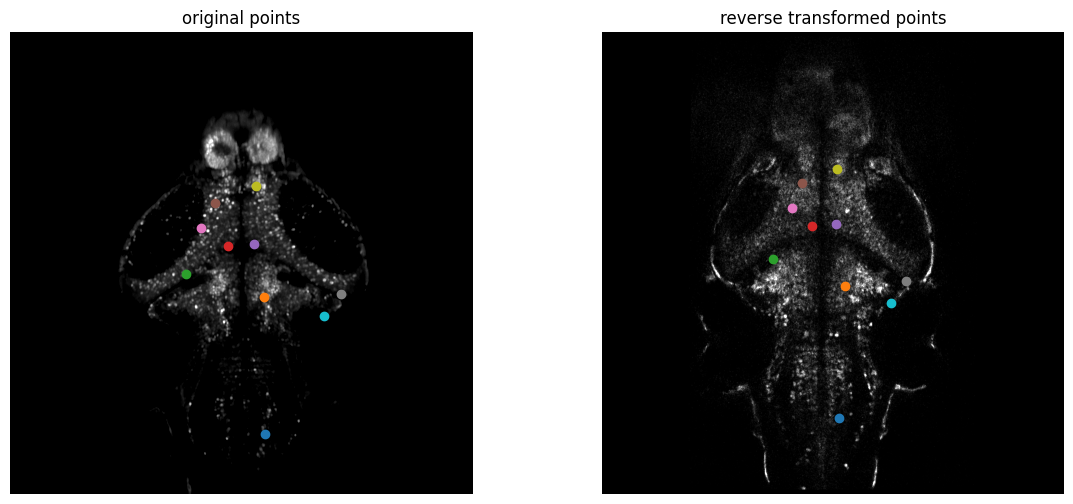

ELASTIX version: 5.0.1
Command line options from ElastixBase:
-out      /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev/
-threads  unspecified, so all available threads are used
-def      /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev/point_set.txt
-jac      unspecified, so no det(dT/dx) computed
-jacmat   unspecified, so no dT/dx computed
Calling all ReadFromFile()'s ...
  The default value "false" is used instead.
  The default value "false" is used instead.
  Calling all ReadFromFile()'s took 0.006933 s
Transforming points ...
  The transform is evaluated on some points, specified in the input point file.
  Reading input point file: /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev/point_set.txt
  Input points are specified in world coordinates.
  Number of specified input points: 10
  The input points are transformed.
  The transformed points are saved in: /V

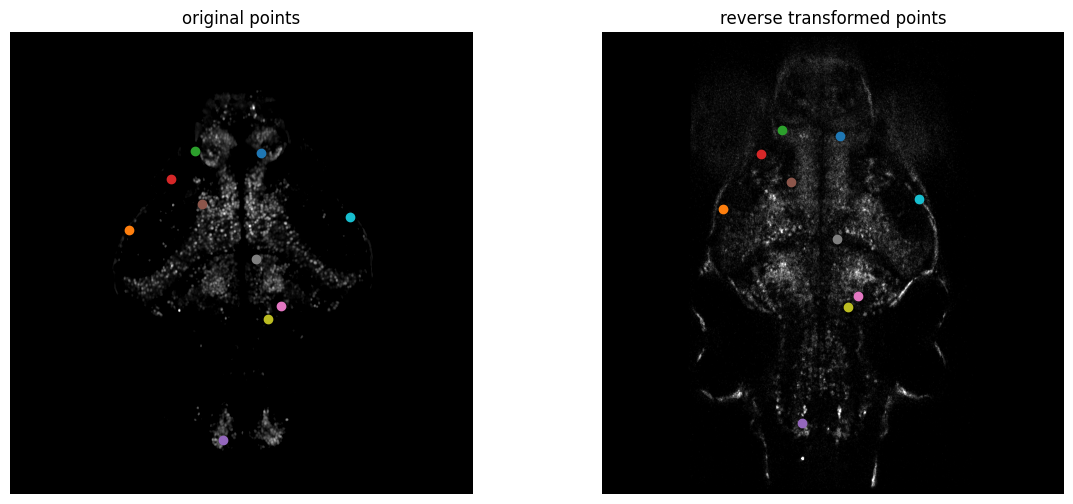

ELASTIX version: 5.0.1
Command line options from ElastixBase:
-out      /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev/
-threads  unspecified, so all available threads are used
-def      /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev/point_set.txt
-jac      unspecified, so no det(dT/dx) computed
-jacmat   unspecified, so no dT/dx computed
Calling all ReadFromFile()'s ...
  The default value "false" is used instead.
  The default value "false" is used instead.
  Calling all ReadFromFile()'s took 0.006280 s
Transforming points ...
  The transform is evaluated on some points, specified in the input point file.
  Reading input point file: /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/alignment_rev/point_set.txt
  Input points are specified in world coordinates.
  Number of specified input points: 10
  The input points are transformed.
  The transformed points are saved in: /V

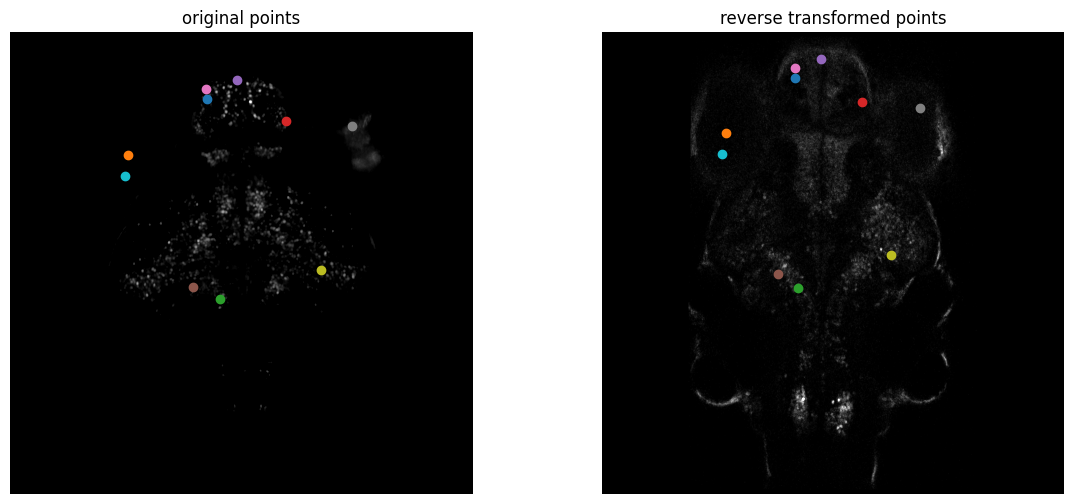

In [32]:
# visualize images
n_points = 10

# Same COM → display mapping as cells above: rot90 CCW in 1024 + (1024-640)/2 on current x.
if "com_to_target_xy" not in globals():
	W_EMBED = 1024
	SHIFT_X_CURRENT = (1024 - 640) // 2

	def com_to_target_xy(x, y):
		px, py = float(x), float(y)
		ox, oy = py, W_EMBED - 1 - px
		return (ox + SHIFT_X_CURRENT, oy)

if "roi_df" not in globals():
	roi_df = df if "df" in globals() else pd.read_hdf(data_folder.joinpath("temporal_pack_compact.h5"))

# plane_idxs[i] = reference (source) stack slice index for target plane i.
# Only the first len(plane_idxs) target planes are tested.
plane_idxs = [11, 15, 19, 23, 27]

if len(target_img_lst) < len(plane_idxs):
    raise ValueError(
        f"Need at least {len(plane_idxs)} target planes, got {len(target_img_lst)}"
    )

for plane, (plot_img, ref_idx) in enumerate(
    zip(target_img_lst[: len(plane_idxs)], plane_idxs)
):
	mypoints = list()
	fish_id = int(exp_folder.name.split('_')[-2])

	coms = random.sample(list(roi_df[(roi_df.fish_id == fish_id) & (roi_df.plane == plane)]["com"]), n_points)
	for x, y in coms:
		mypoints.append(com_to_target_xy(x, y))
		
	rev_points = sitkalignment.transform_points(Path(save_path), mypoints)

	fig, ax = plt.subplots(1, 2, figsize=(14, 6))

	source_plane = source_img_stack[ref_idx, :, :]
	source_plane = sitkalignment.embed_image(source_plane, 1024) # matching image sizes to 1024x1024
	source_plane = source_plane / source_plane.max() # rescaling pixel brightness
	source_plane *= 2**12

	ax[0].imshow(
		plot_img,
		cmap="gray",
		vmin=500,
		vmax=3000,
	)
	for p in mypoints:
		ax[0].scatter(p[0],p[1])
	ax[0].set_title('original points')

	ax[1].imshow(
		source_plane,
		cmap="gray",
		vmin=0,
		vmax=2000,
	)
	ax[1].set_title('reverse transformed points')
	for p in rev_points:
		ax[1].scatter(p[0],p[1])

	[a.axis("off") for a in ax]
	plt.show()


In [ ]:
# Update the unrolled_temporal.h5 dataframe with the reverse transformed points
with os.scandir(data_folder) as exp_folders:
	for exp_f in exp_folders:
		if exp_f.name.startswith("elavl3H2BGCaMP8m"):
			exp_folder = exp_f.path
			save_path = os.path.join(exp_folder, "alignment_rev")

			# Load the unrolled_temporal.h5 file to add the reverse transformed points
			df = pd.read_hdf(os.path.join(exp_folder, "unrolled_temporal.h5"))
			df["com_aligned"] = None
			
			for i, row in df.iterrows():
				rev_point = sitkalignment.transform_points(Path(save_path), [(row.com[0] + 256, row.com[1] + 256)])
				df.at[i, "com_aligned"] = (rev_point[0][0], rev_point[0][1])

			df.to_hdf(os.path.join(exp_folder, "unrolled_temporal.h5") , key='unrolled_temporal', mode='w')

## Label the "neurons" on the skin as non-responsive

In [ ]:
# The elavl3:H2B-GCaMP8m line has autofluorescence in the skin.
# Folder where the masks are to remove the "neurons" on the skin
masks_folder = fr'{arinel_repo_path}/Data/alignment/hindbrain/masks that remove the skin'

with os.scandir(data_folder) as exp_folders:
	for exp_f in exp_folders:
		if exp_f.name.startswith("elavl3H2BGCaMP8m"):
			exp_folder = exp_f.path

			# Load the unrolled_temporal.h5 file to add the reverse transformed points
			df = pd.read_hdf(os.path.join(exp_folder, "unrolled_temporal.h5"))

			with os.scandir(masks_folder) as entries:
				for entry in entries:
					if entry.name.endswith('.tif'):
						mask = imread(entry.path)
						mask = sitkalignment.embed_image(mask, 1024)

						plane = int(entry.name.split(' ')[1])

						# since the images are embedded, instead of finding the points to remove, 
						# we'll find the points to keep instead
						keep_points = np.vstack([np.where(mask == 255)[1], np.where(mask == 255)[0]]).transpose()

						for i, row in df[df.plane == plane].iterrows():
							if not np.any(np.logical_and(keep_points[:, 0] == row["com_aligned"][0], keep_points[:, 1] == row["com_aligned"][1])):
								df.loc[i, "responsive"] = False
								df.loc[i, "activated"] = False
								df.loc[i, "suppressed"] = False

			df.to_hdf(os.path.join(exp_folder, "unrolled_temporal.h5"), key='unrolled_temporal', mode='w')

/var/folders/48/8y2gqcvx5q5575kwkzngl6qw0000gn/T/ipykernel_12151/1566319243.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['fish_id', 'plane', 'neuron', 'raw_temporal', 'temporal',
       'raw_norm_temporal', 'norm_temporal', 'roi_index', 'com',
       'pulse_frames', 'activated', 'suppressed', 'pulse_response',
       'com_aligned'],
      dtype='object')]

  df.to_hdf(os.path.join(exp_folder, "unrolled_temporal.h5"), key='unrolled_temporal', mode='w')
/var/folders/48/8y2gqcvx5q5575kwkzngl6qw0000gn/T/ipykernel_12151/1566319243.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['fish_id', 'plane', 'neuron', 'raw_temporal', 'temporal',
       'raw_norm_temporal', 'norm_temporal', 'roi_index', 'co

(290.0, 690.0, 710.0, 310.0)

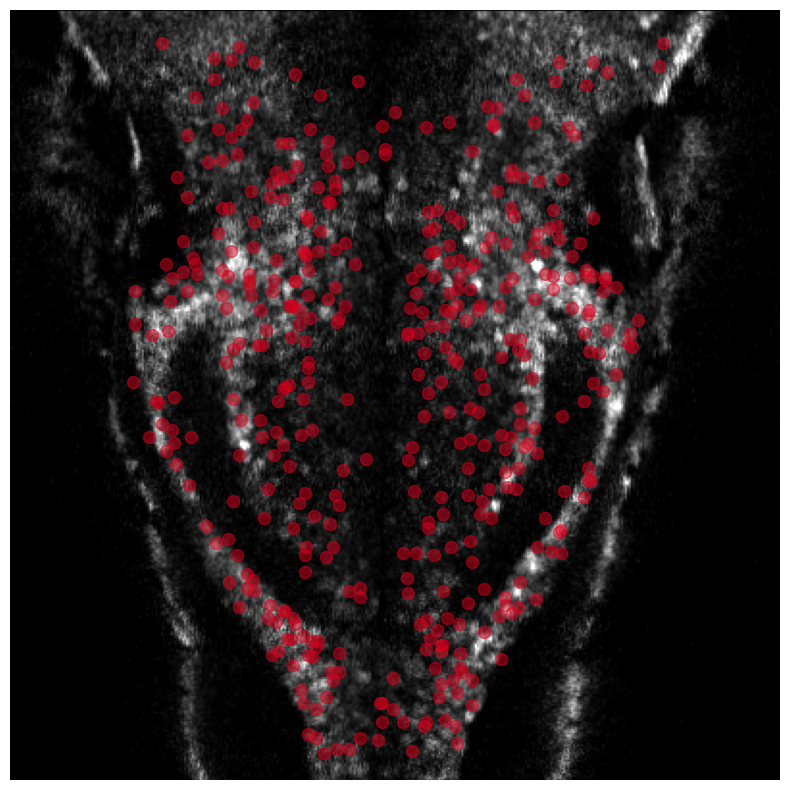

In [ ]:
# Visualize the neurons
# Map df.plane -> reference z slice. plane_idxs[i] must correspond to functional plane id i (not enumerate index from another loop).
plane_idxs = [4, 6, 8, 10, 12]
plane_to_ref_z = {i: z for i, z in enumerate(plane_idxs)}
# If df.plane uses other labels (e.g. 3,5,7,9,11), set plane_to_ref_z explicitly instead.

plane = 2
fig, ax = plt.subplots(figsize=(10, 10))

avg_img = source_img_stack[plane_to_ref_z[plane]]
avg_img = sitkalignment.embed_image(avg_img, 1024)

plt.imshow(avg_img, cmap="gray", vmax=500)

with os.scandir(data_folder) as exp_folders:
	for exp_f in exp_folders:
		if exp_f.name.startswith("elavl3H2BGCaMP8m"):
			exp_folder = exp_f.path

			# Load the unrolled_temporal.h5 file
			df = pd.read_hdf(os.path.join(exp_folder, "unrolled_temporal.h5"))

			for i, com in enumerate(df[(df.responsive == True) & (df.plane == plane)]["com_aligned"]):
				plt.scatter(com[0], com[1], color='#D7001C', alpha=0.5, s=75)

plt.xlim(290, 290+400)
plt.ylim(310+400, 310)
plt.axis('off')

In [ ]:
# Visualize unaligned source and target images
# Change the vmin and vmax settings for better visualization and better alignment
# Increasing the contrast of landmarks helps with the alignment

plane = 0
target_vmin = 400
target_vmax = 1700
source_vmax = 1200
plot_img_line_xval = 0  # blocking out top of functional image with 0's
source_img_line_xval = 0  # blocking out top of reference image with 0's

########################################

# Use mapping created in the batch-alignment cell when available.
# target_img_lst entries are already np.rot90(..., k=3) (90° CW) then embedded.
if 'target_img_by_plane' in globals() and isinstance(target_img_by_plane, dict) and len(target_img_by_plane) > 0:
    if plane not in target_img_by_plane:
        raise ValueError(
            f"Plane {plane} not available. Detected planes: {sorted(target_img_by_plane.keys())}"
        )
    plot_img = target_img_by_plane[plane]
    target_idx = None
else:
    if plane >= len(target_img_lst):
        raise ValueError(f"Index {plane} out of range for {len(target_img_lst)} target images")
    print(f"[WARN] target_img_by_plane missing; using list index {plane} as fallback.")
    plot_img = target_img_lst[plane]
    target_idx = plane

fig, ax = plt.subplots(1, 3, figsize=(14, 6))

_plot_img = plot_img.copy()
_plot_img[0:plot_img_line_xval] = 0

_source_img = source_img.copy()
_source_img[0:source_img_line_xval] = 0

ax[0].imshow(
    _source_img,
    cmap="gray",
    vmin=0,
    vmax=source_vmax  # max is 4096
)
ax[1].imshow(
    _plot_img,
    cmap="gray",
    vmin=target_vmin,
    vmax=target_vmax  # max is 4096
)

[a.axis("off") for a in ax]

merge = np.zeros(
    (_source_img.shape[0], _source_img.shape[1], 3)
)  # assumes same size images
merge[:, :, 0] = 2 * _source_img / _source_img.max()
merge[:, :, 1] = 2 * _plot_img / _plot_img.max()
ax[-1].imshow(merge)

ax[0].set_title("reference")
if target_idx is None:
    ax[1].set_title(f"target (plane {plane}, mapped)")
else:
    ax[1].set_title(f"target (fallback idx {target_idx})")
ax[-1].set_title("merge")
plt.show()
